In [5]:
import scanpy as sc
import pandas as pd
import numpy as nu
from scipy.sparse import csr_matrix

from matplotlib import pyplot as plt
from matplotlib import rcParams
%matplotlib inline
import sys

In [2]:
import sys
sys.path.append('../src/resolute')
import resolute as rs

In [3]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=200, facecolor='white')

## 3kPBMC dataset

"K-means clustering on the first 50 PCs identified 10 distinct cell clusters, which were visualized in two-dimensional projection of t-distributed stochastic neighbour embedding (tSNE)..."
— Zheng et al., Nature Communications, 2017, page 5

But they were using PBMC 68k

https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering-2017.html

Scanpy tutorial on 3k dataset finds and annotates 8 clusters


In [6]:
adata = sc.read_h5ad("../../tests/datasets/3kPBMC_data/processed_data.h5ad")

--- Running CALINSKI Scoring ---
Performing 19 parallel clusterings, using 19/64 CPU cores


Optimizing CALINSKI: 100%|██████████| 19/19 [00:05<00:00,  3.49it/s]


Detected 6 local minima at resolutions: [0.30000000000000004, 0.5, 0.9, 1.1, 1.5000000000000002, 1.8000000000000003]
Suggested Resolution (Deepest Dip): 0.30

--- Running Bootstrap Stability Analysis (optimized) ---
Performing 19 parallel bootstraps (50 iterations each), using 19/64 CPU cores


Evaluating Stability: 100%|██████████| 19/19 [00:28<00:00,  1.48s/it]


Detected 6 stable local maxima at resolutions: [0.5, 0.8, 1.0, 1.3000000000000003, 1.5000000000000002, 1.8000000000000003]
Suggested Stability Resolution (Highest Peak): 0.50


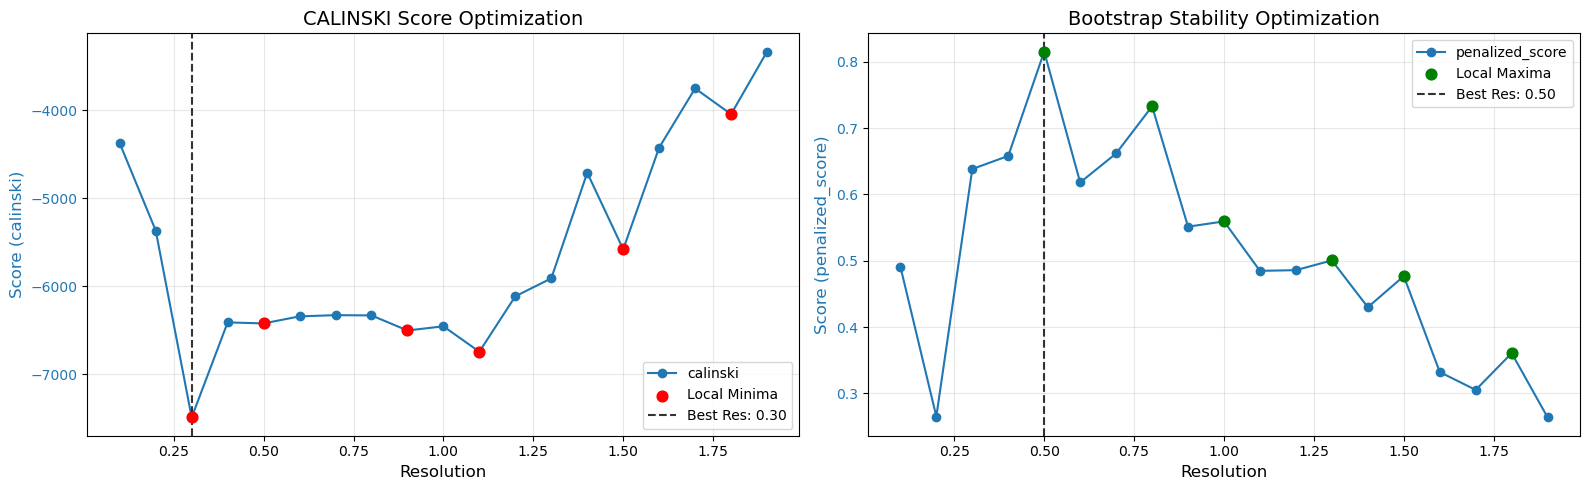


Optimization Summary for CALINSKI & Stability
-----------------------------------------------------------------------------------------------------
Resolution | CALINSKI Score   | Clusters (clustering_score) | Stability Score  | Clusters (Stability)
-----------------------------------------------------------------------------------------------------
0.1        | -4378.0783       | 4                           | 0.4912           | 4                   
0.2        | -5368.0377       | 5                           | 0.2651           | 5                   
0.3        | -7488.6965       | 5                           | 0.6382           | 5                   
0.4        | -6409.9435       | 6                           | 0.6580           | 6                   
0.5        | -6421.7420       | 6                           | 0.8152           | 6                   
0.6        | -6341.7332       | 7                           | 0.6179           | 7                   
0.7        | -6327.8984       | 7  

In [7]:
results = rs.run_resolute(
    adata, 
    score_value='calinski', 
    use_rep='X_umap', 
    stability_use_rep = 'X_pca',
    compute_stability=True, 
    n_iterations=50
)


/shared/home/ssarnata/.conda/envs/spatialdata/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


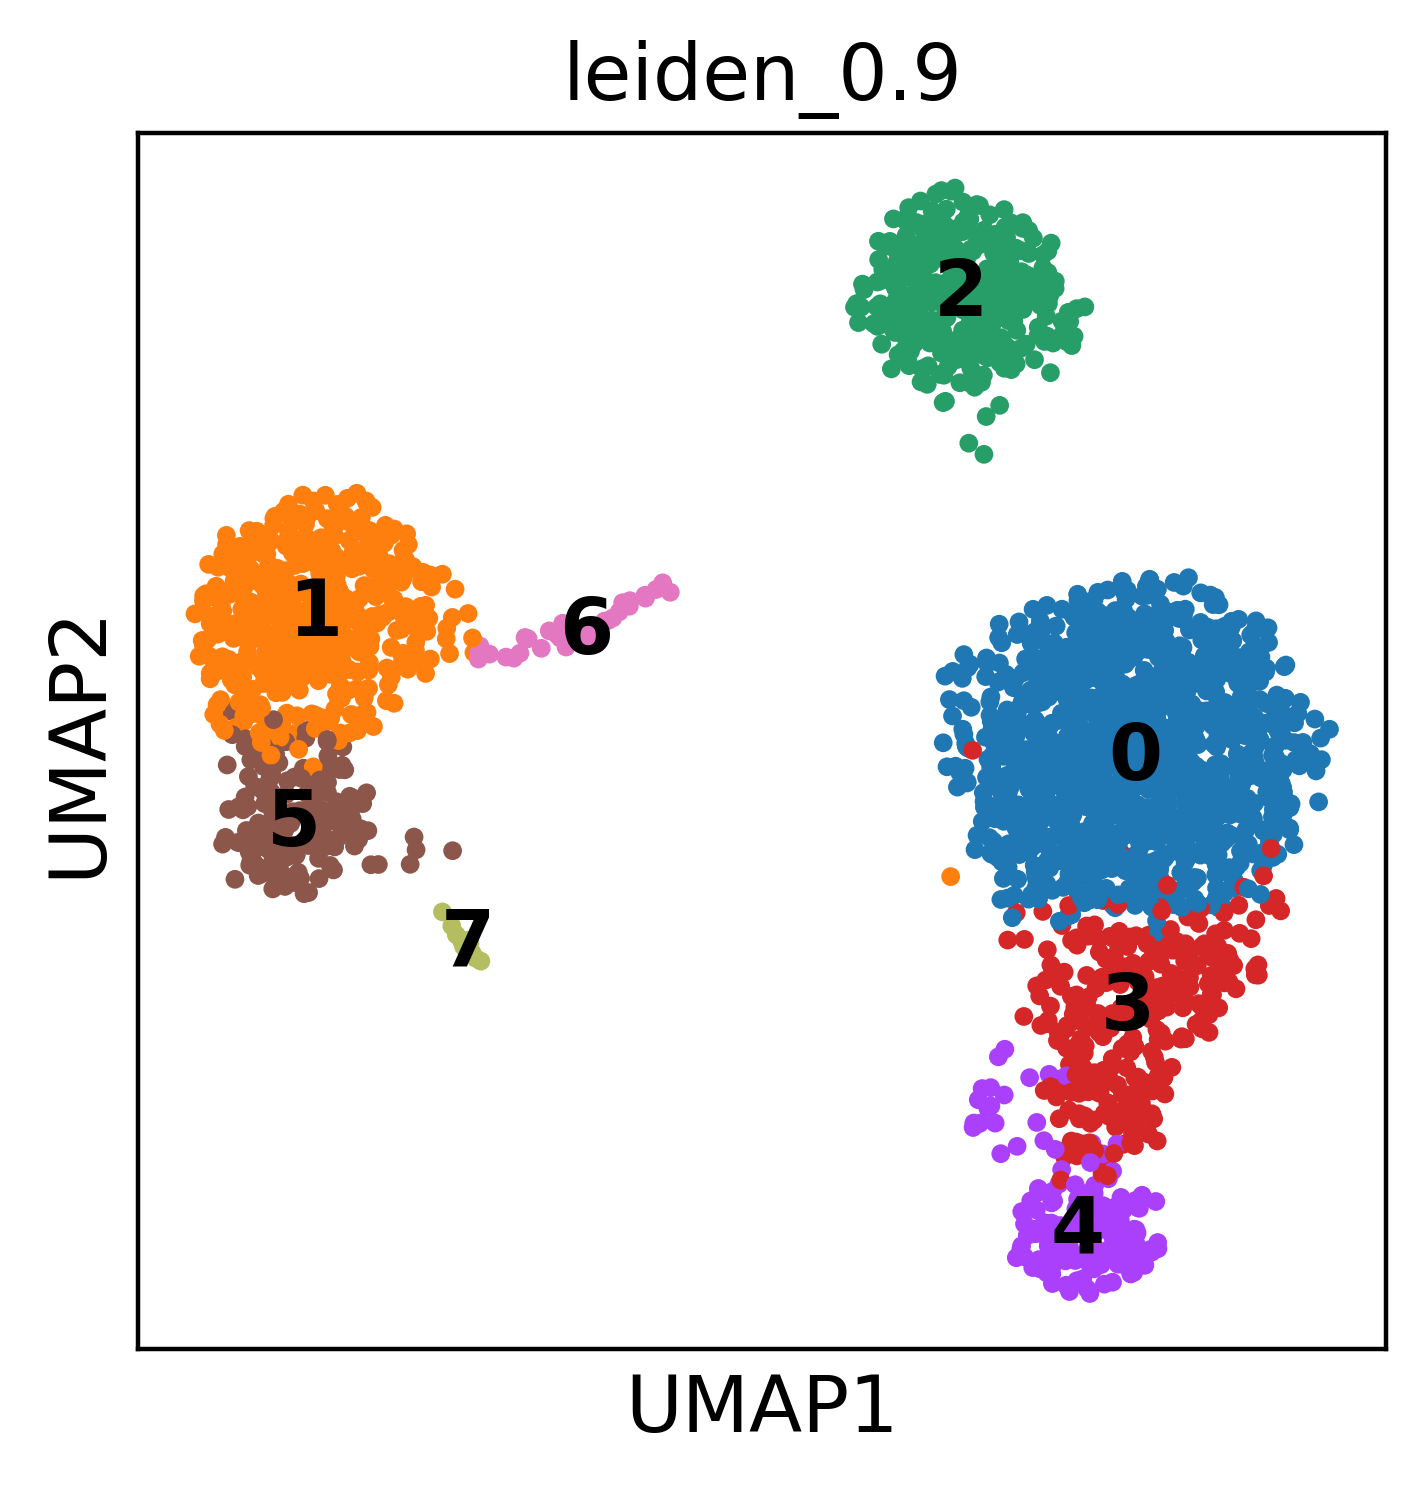

/shared/home/ssarnata/.conda/envs/spatialdata/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


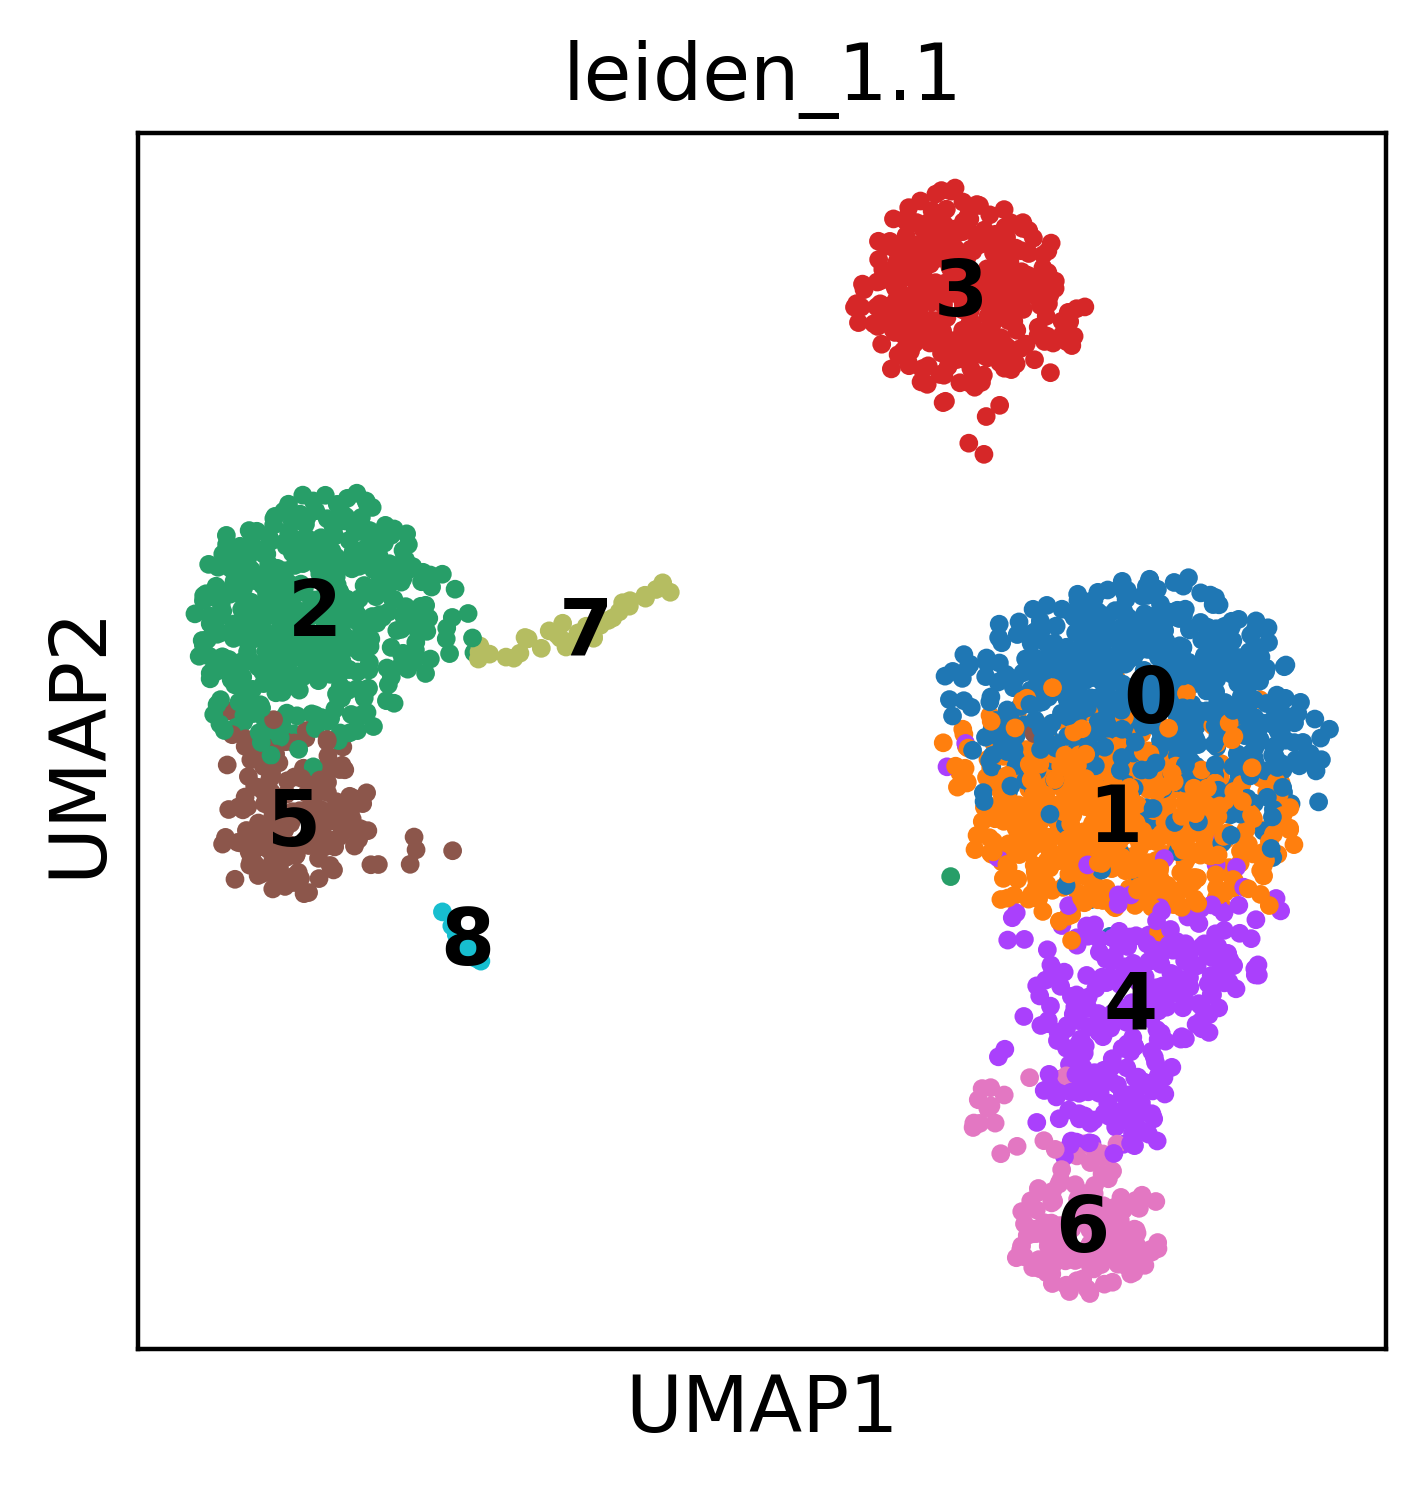

In [19]:
for res in [0.9,1.1]:
    sc.tl.leiden(adata, key_added="leiden_%s" %res, resolution=res)
    sc.pl.umap(adata, color="leiden_%s" %res,legend_loc="on data")

reference is 8 clusters